# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

#**Customer Personality Segmentation**

An increasingly competitive retail landscape, a "one-size-fits-all" marketing strategy is no longer effective. To drive growth and enhance customer loyalty, businesses must understand the unique profiles of their customers. This project focuses on a leading retail company that aims to move beyond generic outreach by leveraging data-driven insights into customer personalities, lifestyles, and purchasing habits.

The primary goal of this analysis is to identify distinct customer segments using Machine Learning (K-means Clustering). By grouping customers with similar characteristics, the company can:

1-Personalize Marketing: Create tailored campaigns that resonate with specific group needs, significantly increasing conversion rates.

2-Optimize Resources: Allocate budget and inventory more efficiently by focusing on high-value segments and understanding the needs of budget-conscious families.

# **Let's start coding!**

## **Importing necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [3]:
# loading data into a pandas dataframe
data = pd.read_csv("Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:**
Integer (int64):
There are 25 integer columns, representing a mix of identifiers (e.g., ID), counts (e.g., Kidhome, NumWebPurchases), binary campaign indicators (e.g., AcceptedCmp1–AcceptedCmp5, Response), and discrete spending and behavior-related variables. These variables capture customer demographics, purchasing behavior, and interactions with marketing campaigns.

Float (float64):
There is one continuous variable, Income, which represents the customer’s yearly household income.

Object (object):
There are three categorical columns: Education, Marital_Status, and Dt_Customer. The first two represent customer demographic characteristics, while Dt_Customer stores the date when the customer enrolled with the company.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [5]:
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
a=data['Income'].mean()
print("the average household income is ", round(a,2))

the average household income is  52247.25


##### **Observations:**

Household Income & Outliers:
The average household income is approximately 52,247.25, with a median of 51,381.50, indicating a relatively balanced central tendency. However, the maximum value of 666,666 suggests the presence of extreme outliers, which may influence distance-based methods and should be carefully handled during pre-processing.

Recency:
The average recency is 49.1 days, with values ranging from 0 to 99 days. This indicates a wide spread of customer purchase recency, without concentration exclusively on either very recent or very old activity.

Spending Behavior:
Average spending is highest for wine (mean ≈ 304) and meat products (mean ≈ 167). The large standard deviations across spending categories (e.g., wine std ≈ 336) indicate substantial variability in expenditure levels among customers.

Purchasing Channels:
On average, customers make more purchases through physical stores (mean ≈ 5.79) than via web (mean ≈ 4.08) or catalogs (mean ≈ 2.66). Additionally, the average number of web visits per month (≈ 5.32) suggests frequent online interaction, regardless of the final purchase channel.

Campaign Engagement:
Acceptance rates for previous marketing campaigns are low, with mean values below 0.08. The response rate to the most recent campaign is higher (≈ 14.9%), indicating a modest increase in customer engagement.

Constant Variables:
The variables Z_CostContact and Z_Revenue exhibit **zero variance (std = 0)**, meaning they do not contribute information for differentiation and can be removed prior to modeling.

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [7]:
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
income_median = data['Income'].median()

data['Income'] = data['Income'].fillna(income_median)

print("\nMissing values in Income after treatment:", data['Income'].isnull().sum())


Missing values in Income after treatment: 0


##### **Observations:**
Missing Value Identification:
The dataset contains missing values only in the Income variable, with 24 missing entries. Given a total of 2,240 observations, this represents approximately 1% of the dataset, indicating a limited amount of missing data.

Imputation Strategy:
The missing values in Income were imputed using the median of the variable.

Justification:
The median was selected instead of the mean because the Income distribution includes extreme values, as evidenced by the unusually high maximum income. Using the median reduces the influence of outliers and preserves a more robust representation of central tendency, which is particularly important for distance-based methods such as clustering.

Verification:
After imputation, all variables contain no remaining missing values, confirming the successful treatment of missing data.

#### **Question 4**: Are there any duplicates in the data?

In [9]:
duplicate_count = data.duplicated().sum()

print(f"Number of duplicate rows in the dataset: {duplicate_count}")

id_duplicates = data['ID'].duplicated().sum()
print(f"Number of duplicate Customer IDs: {id_duplicates}")

Number of duplicate rows in the dataset: 0
Number of duplicate Customer IDs: 0


##### **Observations:**
Row-level Redundancy: There are 0 duplicate rows in the dataset. This indicates that the data collection process did not result in identical records being entered multiple times.

Unique Identification: There are 0 duplicate Customer IDs. Since the ID column serves as the primary key for the dataset, the absence of duplicates confirms that each entry corresponds to a unique customer profile.

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

In [10]:
print(data['Education'].unique())

map1 = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}

data['Education_Map'] = data['Education'].map(map1)

data['Age'] = 2026 - data['Year_Birth']

columns_to_drop = [
    'ID',
    'Dt_Customer',
    'Year_Birth',
    'Z_CostContact',
    'Z_Revenue',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Complain',
    'Response'
]

data.drop(columns=columns_to_drop, inplace=True)

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


##### **Variable Selection and Pre-processing Justification:**
Removal of Identifier and Constant Variables:
The variables ID, Z_CostContact, and Z_Revenue were removed because they do not contain meaningful variability for customer segmentation. ID is a unique identifier with no analytical value, while Z_CostContact and Z_Revenue exhibit zero variance, meaning they cannot contribute to distance-based clustering.

Transformation of Year_Birth into Age:
The variable Year_Birth was transformed into Age to provide a more interpretable and directly comparable demographic measure. Age better reflects customer life stage and allows for more intuitive interpretation of cluster characteristics than raw birth year values.

Handling of Categorical Variables:
Since K-means requires numerical inputs, categorical variables were treated accordingly. Marital_Status was excluded due to its nominal nature and lack of inherent ordering, which makes direct numerical encoding unsuitable for distance-based methods.
In contrast, **Education was transformed** into an ordinal numerical variable, preserving the natural educational hierarchy (Basic < 2n Cycle < Graduation < Master < PhD) while enabling its inclusion in the clustering process.

Exclusion of Campaign Response Variables:
The campaign response indicators (AcceptedCmp1–AcceptedCmp5) were excluded to reduce noise and avoid clustering customers primarily based on their reactions to specific marketing campaigns. The objective was to focus segmentation on underlying demographic and purchasing behavior, rather than past campaign outcomes.

Exclusion of Binary Outcome Variables:
The binary variables Complain and Response were removed to prevent disproportionate influence in distance-based clustering. These variables were retained for post-cluster analysis, where they can be used to interpret and compare cluster behavior after segmentation.

Income
Skew : 6.8


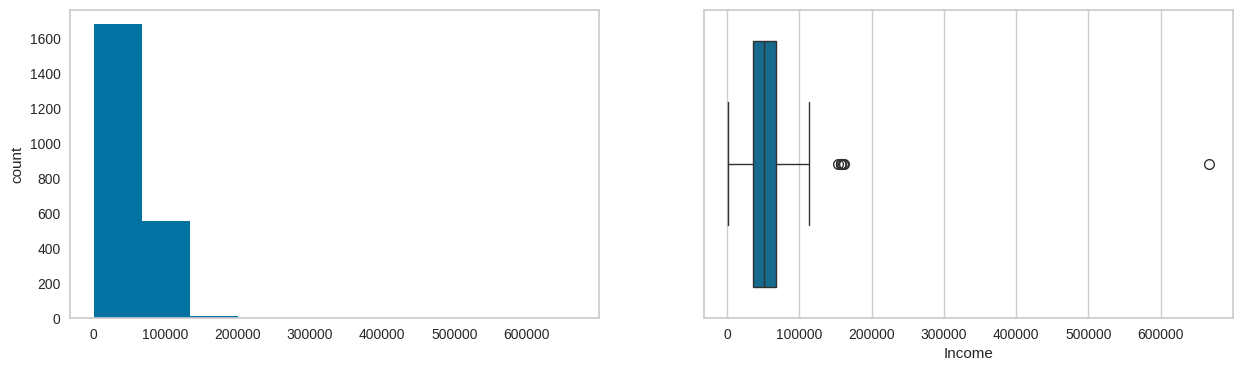

Kidhome
Skew : 0.64


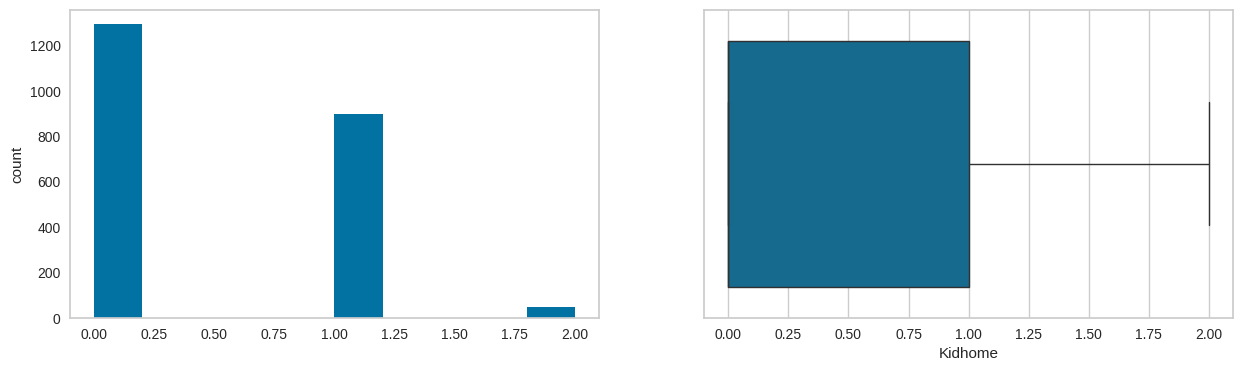

Teenhome
Skew : 0.41


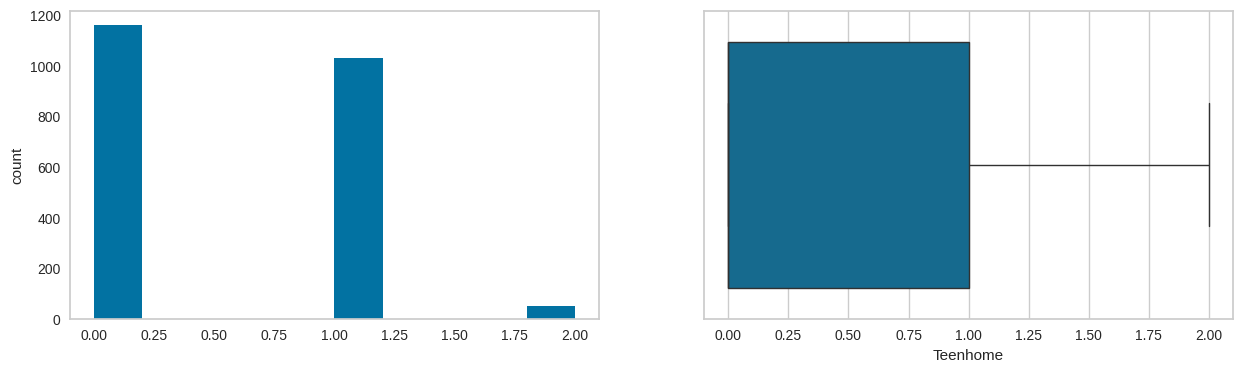

Recency
Skew : -0.0


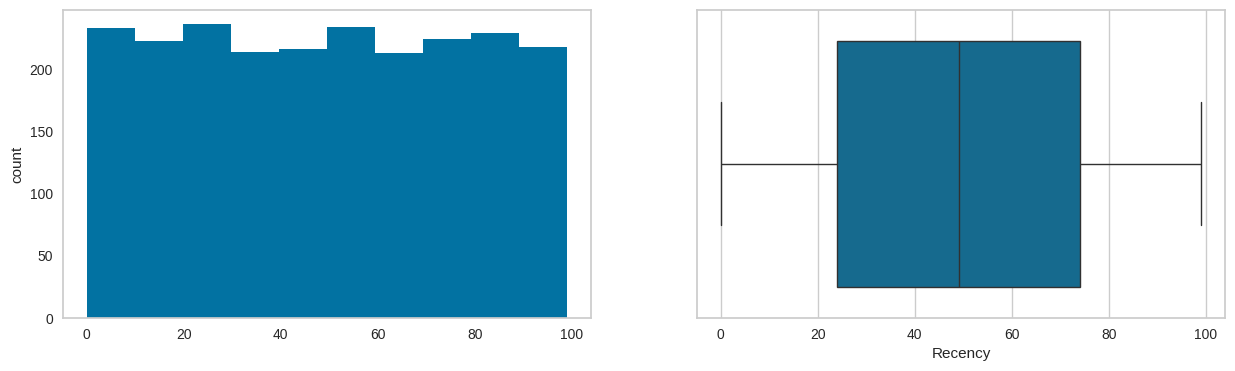

MntWines
Skew : 1.18


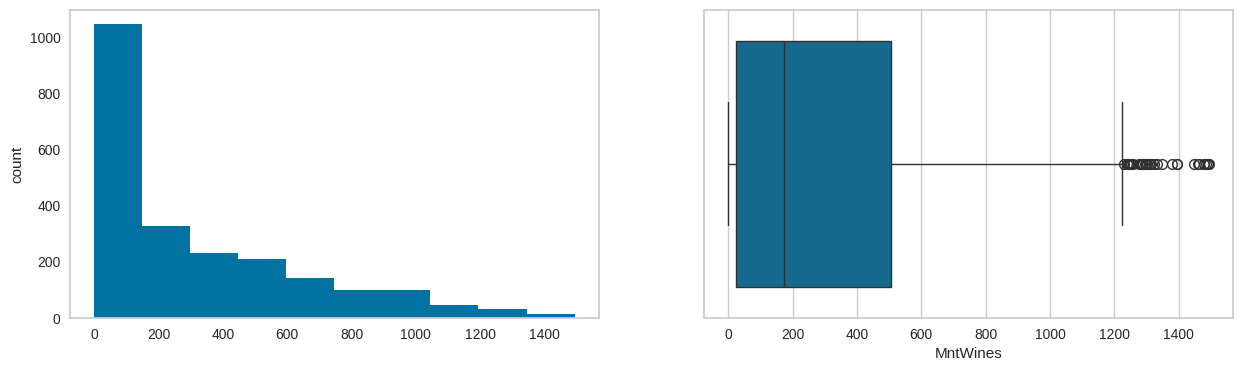

MntFruits
Skew : 2.1


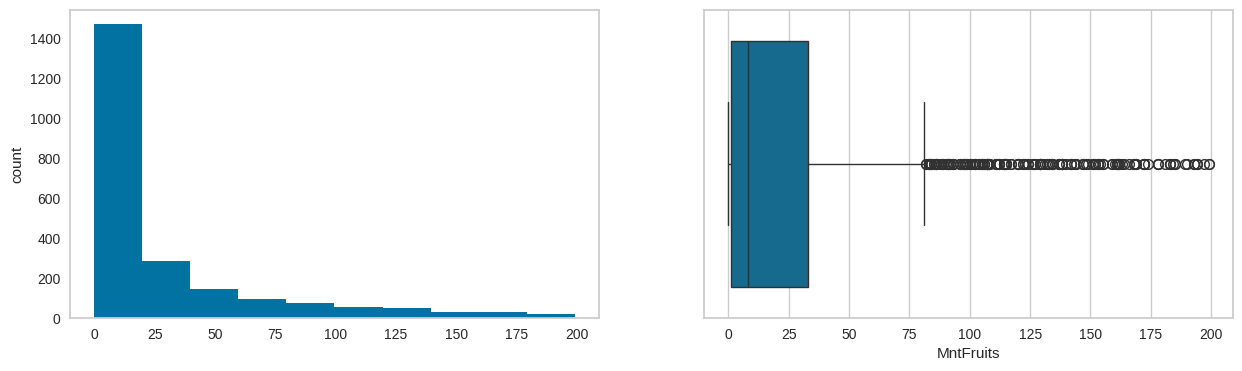

MntMeatProducts
Skew : 2.08


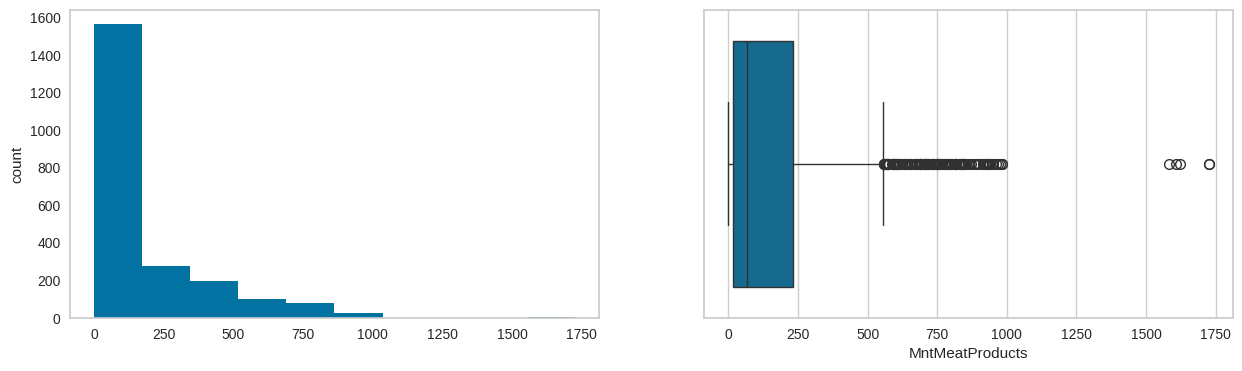

MntFishProducts
Skew : 1.92


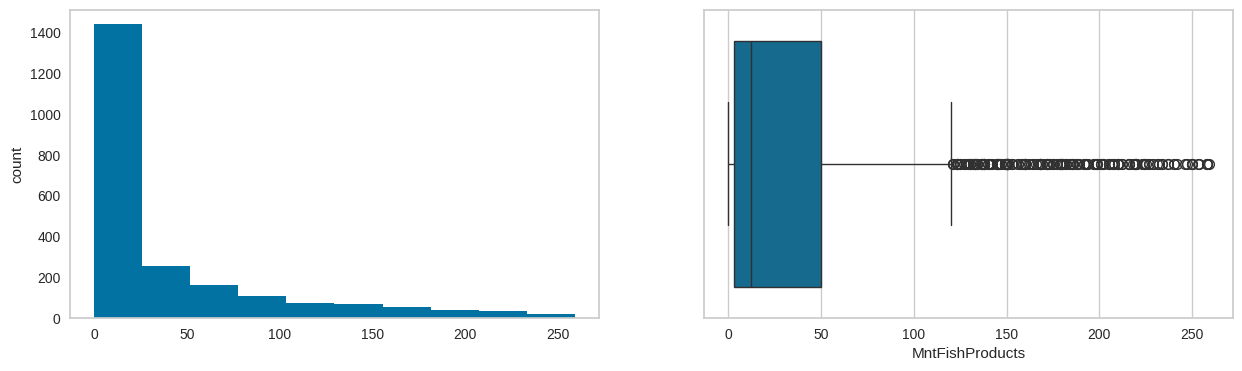

MntSweetProducts
Skew : 2.14


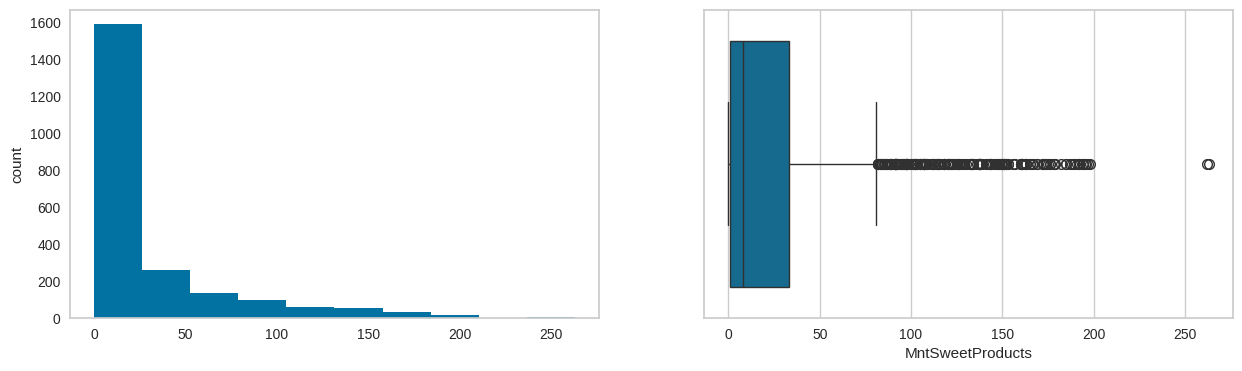

MntGoldProds
Skew : 1.89


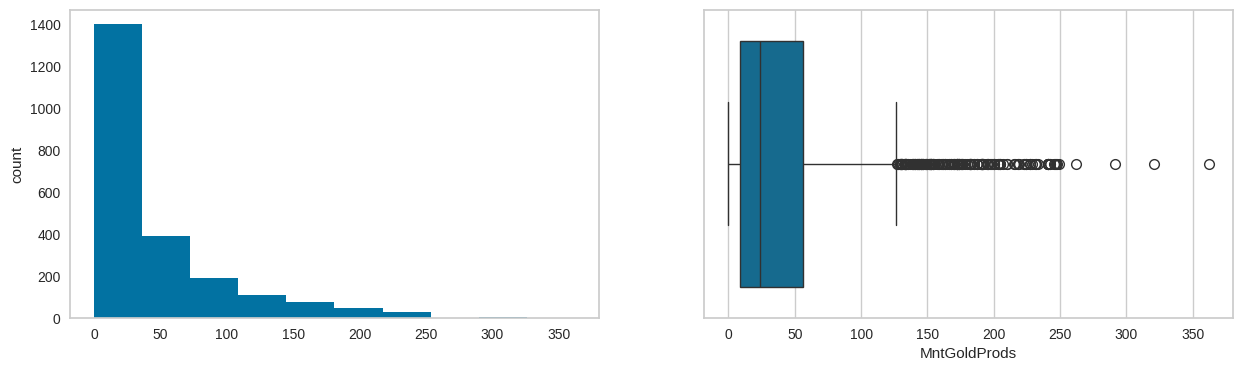

NumDealsPurchases
Skew : 2.42


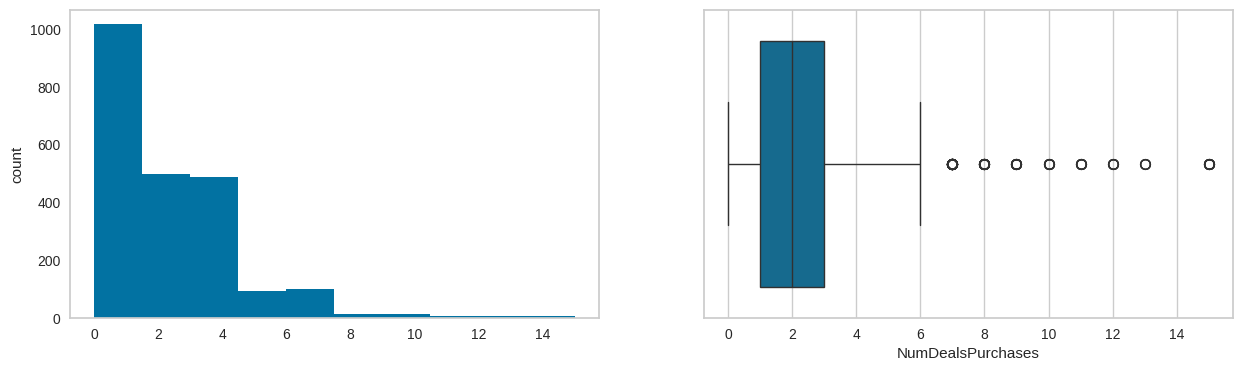

NumWebPurchases
Skew : 1.38


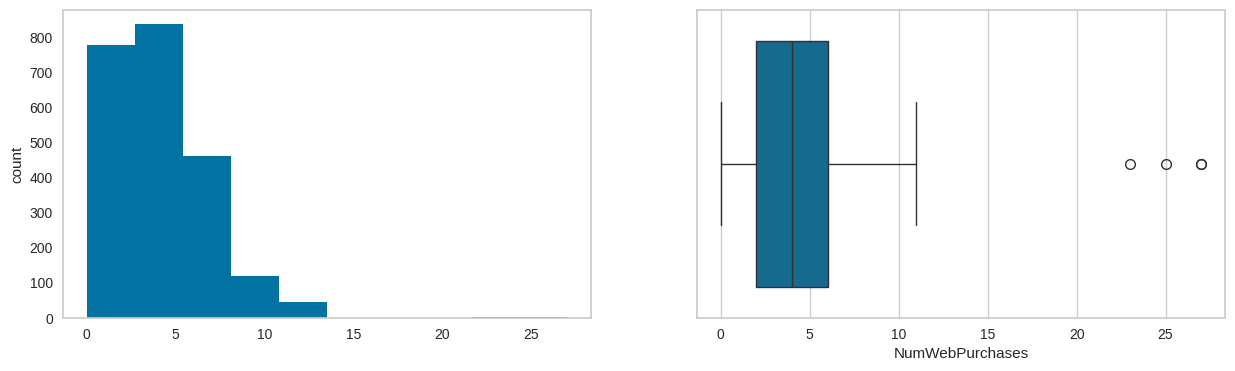

NumCatalogPurchases
Skew : 1.88


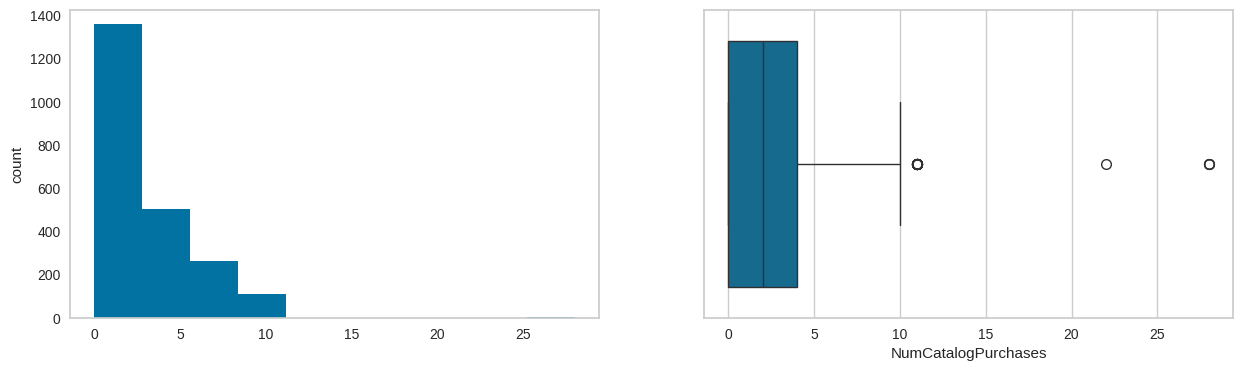

NumStorePurchases
Skew : 0.7


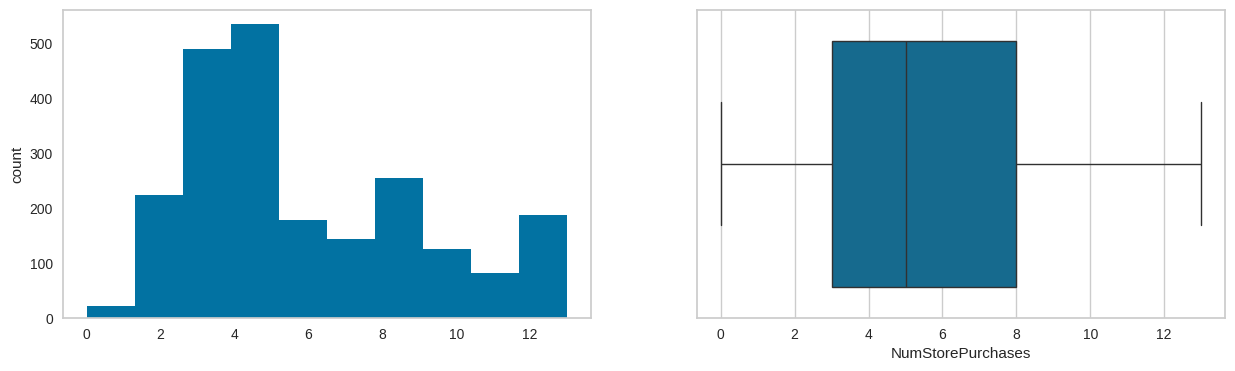

NumWebVisitsMonth
Skew : 0.21


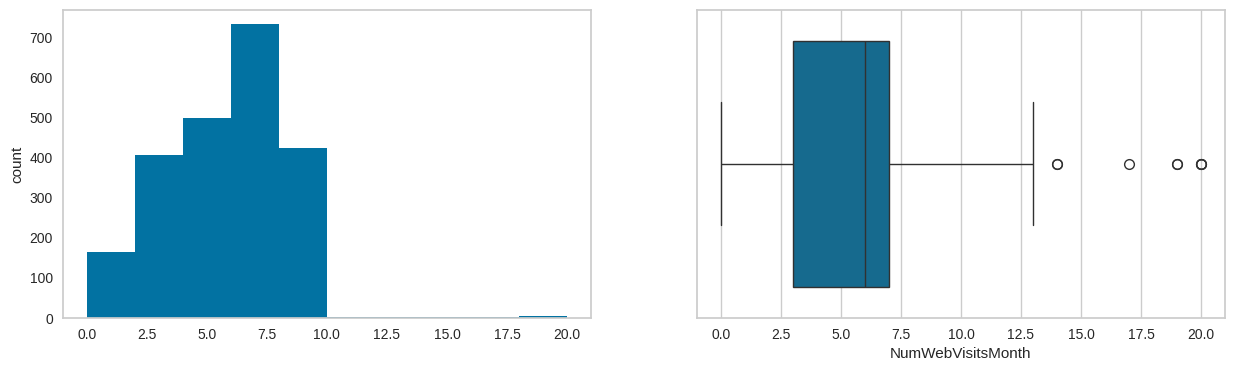

Education_Map
Skew : 0.13


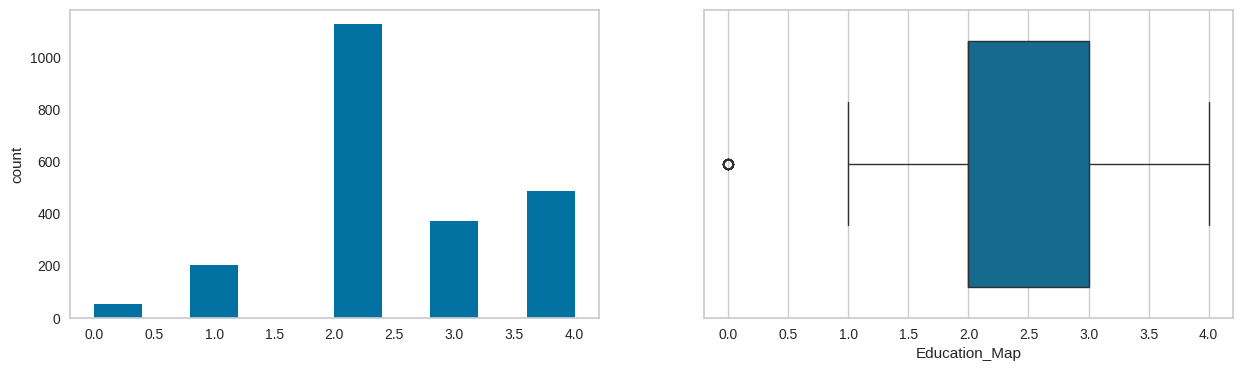

Age
Skew : 0.35


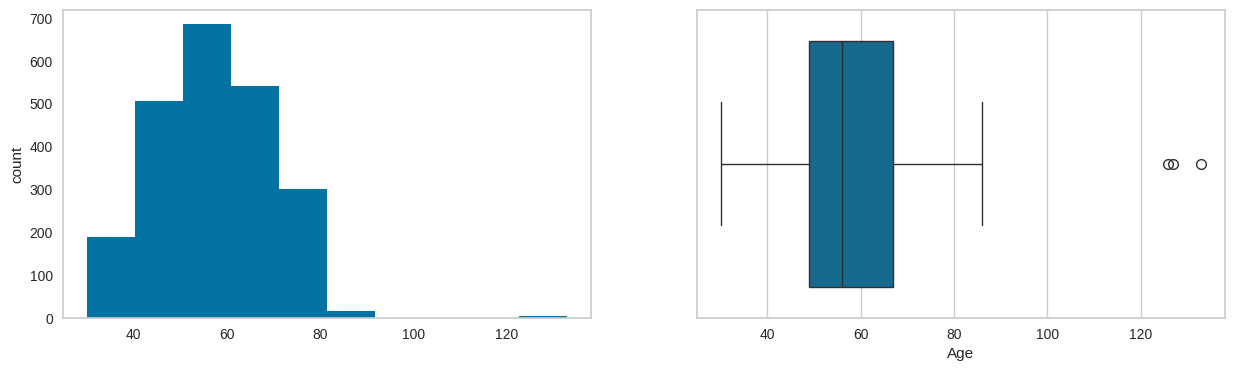

In [11]:
cont_cols = data.select_dtypes(include=['int64','float64']).columns
for col in cont_cols:
    print(col)
    print('Skew :',round(data[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data[col].hist(bins=10, grid=False)
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.show()


##### **Observations:**
The distribution plots indicate that Income is highly right-skewed, showing a strong concentration of lower values and the presence of extreme outliers.
Several spending-related variables, including MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, as well as NumDealsPurchases, are also strongly right-skewed, with visible outliers in the boxplots.

Variables such as MntWines, NumWebPurchases, NumCatalogPurchases, and NumStorePurchases exhibit moderate right skewness, indicating asymmetric distributions with some high-value outliers.

Kidhome, Teenhome, Age, NumWebVisitsMonth, and Education_Map show low skewness, suggesting relatively balanced distributions with fewer extreme values.

Recency presents an approximately symmetric distribution, with skewness close to zero.

#####**Outliers:**

Outlier treatment was approached selectively, based on both data plausibility and business relevance, rather than applying a uniform removal or capping strategy.

With respect to Income and spending-related variables (such as MntWines and MntMeatProducts), extreme values were intentionally retained. Although these observations appear as statistical outliers, they may represent genuine high-value customers (e.g., High-Net-Worth Individuals). From a business perspective, such customers are often among the most profitable segments, and removing or capping these values could distort their true purchasing power and weaken the segmentation results. Additionally, after applying StandardScaler, the influence of scale differences is mitigated while preserving the relative structure of the data, allowing K-means to naturally isolate these customers into distinct clusters if appropriate.

In contrast, outliers in the Age variable were treated differently. A small number of customers exhibited unrealistically high ages (e.g., values exceeding 100 years), which are unlikely to represent valid customer profiles and are more indicative of data entry errors or anomalies. Since age is a key demographic feature used for segmentation, retaining such implausible values could distort distance calculations and adversely affect cluster formation. Given that these cases represent a very small proportion of the dataset, they were removed during pre-processing to improve data quality without materially impacting the overall analysis.

In [12]:
data['Age'].max()

133

In [13]:
data[['Age', 'Recency']].sort_values(by='Age', ascending=False).head(3)


,Age,Recency
239,133,23
339,127,36
192,126,99


In [14]:
data = data[data['Age'] <= 100]

##### **Observation:**
These observations likely result from anomalous birth-year entries and were therefore removed from the dataset.

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

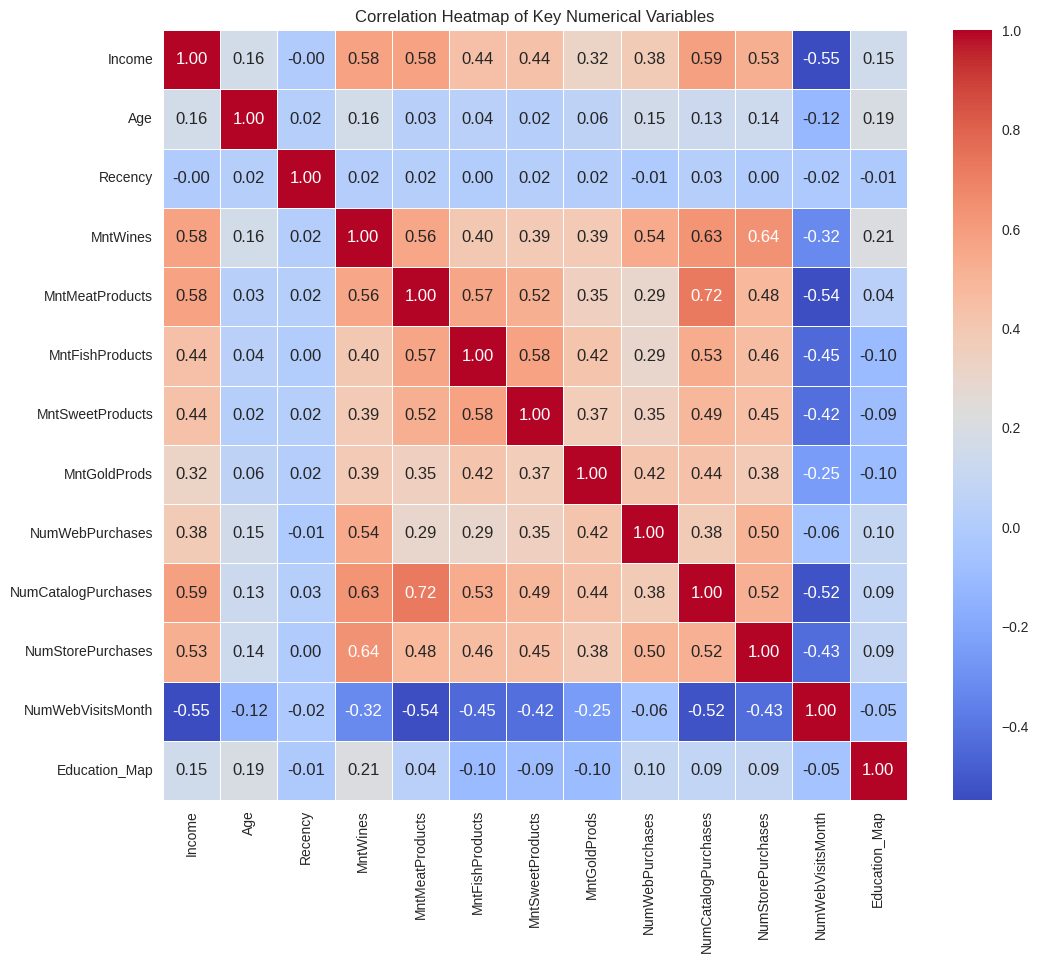

In [88]:
corr_features = [
    'Income',
    'Age',
    'Recency',
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Education_Map'
]

corr_matrix = data[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title('Correlation Heatmap of Key Numerical Variables')
plt.show()

##### **Observations:**
Overall, the correlation matrix does not exhibit strong linear relationships among variables. Most correlations fall within the weak to moderate range, with no coefficients exceeding 0.72 in absolute value.

Moderate positive correlations are observed mainly among spending-related variables and purchase frequency variables, such as:

MntMeatProducts and NumCatalogPurchases ( 0.72 )

MntWines and NumStorePurchases ( 0.64 )

A moderate negative correlation is observed between NumWebVisitsMonth and Income (-0.55), suggesting an inverse relationship, although the strength of this association remains limited.

Variables such as Education_Map and Recency show consistently low correlations with most other features, indicating limited linear association with the rest of the dataset.

## **K-means Clustering**

#### **Scaling the data**

In [89]:
features = [
    'Income', 'Age', 'MntWines', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth'
]

data_for_clustering = data[features]

scaler = StandardScaler()

data_scaled = pd.DataFrame(scaler.fit_transform(data_for_clustering), columns=features)

data_scaled.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Income,2237.0,0.0,1.0,-2.02,-0.67,-0.03,0.64,24.54
Age,2237.0,0.0,1.0,-2.32,-0.69,-0.09,0.85,2.47
MntWines,2237.0,0.0,1.0,-0.90,-0.83,-0.39,0.59,3.53
MntMeatProducts,2237.0,-0.0,1.0,-0.74,-0.67,-0.44,0.29,6.91
MntFishProducts,2237.0,0.0,1.0,-0.69,-0.63,-0.47,0.23,4.05
MntSweetProducts,2237.0,-0.0,1.0,-0.66,-0.63,-0.46,0.14,5.71
MntGoldProds,2237.0,0.0,1.0,-0.84,-0.67,-0.38,0.23,6.11
NumWebPurchases,2237.0,0.0,1.0,-1.47,-0.75,-0.03,0.69,8.25
NumCatalogPurchases,2237.0,0.0,1.0,-0.91,-0.91,-0.23,0.46,8.67
NumStorePurchases,2237.0,0.0,1.0,-1.78,-0.86,-0.24,0.68,2.22


#####**Observations:**
**Justification for Scaling:** K-means clustering is a distance-based algorithm that relies on Euclidean distance to form clusters. In our dataset, variables have very different scales; for example, Income has values in the tens of thousands, while Kidhome ranges from 0 to 2. Without scaling, the algorithm would assign a disproportionately high weight to Income, treating it as the most important feature simply because of its magnitude.

**Methodology:** We applied the StandardScaler (Z-score normalization) to all numerical features. This transforms the data so that each variable has a mean of 0 and a standard deviation of 1.

**Impact:** This process ensures that all features contribute equally to the distance calculations, allowing the model to identify segments based on the actual relationship between variables rather than their unit of measurement.

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

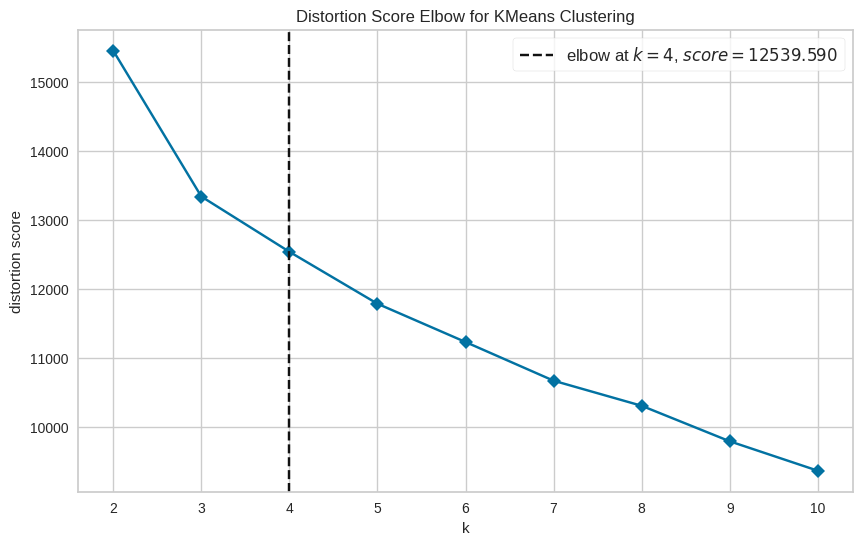

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [90]:
model = KMeans(random_state=1, n_init=10)
visualizer = KElbowVisualizer(model, k=(2, 11), timings=False)

plt.figure(figsize=(10, 6))
visualizer.fit(data_scaled)
visualizer.show()

##### **Observations:**
Although the elbow appears visible at $k=3$, the KElbowVisualizer mathematically identifies the optimal inflection point at $k=4$ (Distortion Score: 12539). This suggests that a 4-cluster solution provides a more granular segmentation, potentially capturing a specific niche of customers that would otherwise be merged into a larger group.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

In [47]:
k_values = [2, 3, 4, 5, 6]
silhouette_avg = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=1, n_init=10)
    cluster_labels = model.fit_predict(data_scaled)
    silhouette_avg.append(silhouette_score(data_scaled, cluster_labels))

silhouette_df = pd.DataFrame({'k': k_values, 'Silhouette Score': silhouette_avg})
print(silhouette_df)

   k  Silhouette Score
0  2          0.378130
1  3          0.302158
2  4          0.182838
3  5          0.180943
4  6          0.182891


##### **Observations:**
The Silhouette Score was used to further validate the optimal number of clusters. The results show that the highest silhouette score is obtained for k = 2, indicating strong separation when the data is divided into two broad clusters. However, this solution results in overly coarse segmentation, which provides limited practical insight for customer profiling.

The Elbow Method, on the other hand, identifies k = 4 as the point where reductions in distortion become marginal. Although the silhouette score decreases for higher values of k, this behavior is expected as the number of clusters increases and the segmentation becomes more granular.

The Choice of $k=3$: Although $k=4$ was the algorithmic suggestion, $k=3$ was selected as the final model. Visually, the "elbow" in the plot is already quite prominent at 3, and it maintains a much healthier Silhouette Score (0.302) than $k=4$.

##### **PCA**
PCA reduces dimensionality while preserving most of the variance, making cluster structure easier to visualize.

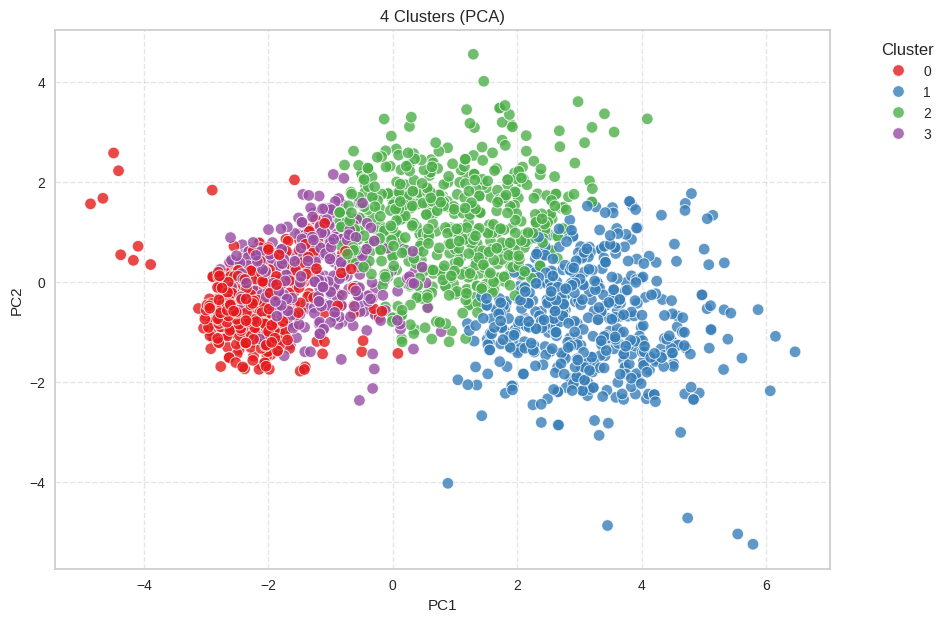

In [91]:
from sklearn.decomposition import PCA

#4
final_model = KMeans(n_clusters=4, random_state=1, n_init=10)
cluster_labels = final_model.fit_predict(data_scaled)
data['Cluster'] = cluster_labels

pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', s=70, alpha=0.8)
plt.title('4 Clusters (PCA)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

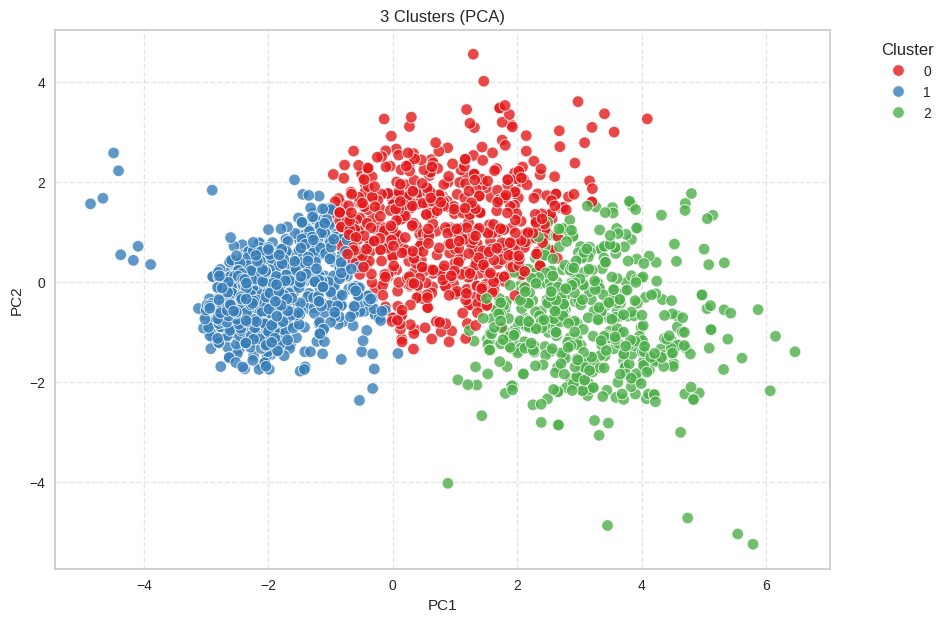

In [92]:
#3
final_model = KMeans(n_clusters=3, random_state=1, n_init=10)
cluster_labels = final_model.fit_predict(data_scaled)
data['Cluster'] = cluster_labels


pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', s=70, alpha=0.8)
plt.title('3 Clusters (PCA)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##### **Observations:**
The PCA visualization was used to project the high-dimensional customer data into two principal components for interpretability.

When using 3 clusters, the PCA plot shows better-defined and more compact groups, with clearer separation between clusters. This indicates that, in two-dimensional space, customer segments present more distinct behavioral patterns, making the clustering structure easier to interpret visually.

#####**Choice:**
Final Decision: Selection of k=3

After evaluating the Elbow Method, Silhouette Scores, and PCA visualizations, k=3 was chosen as the optimal number of clusters for the following reasons:

Balanced Performance: While the Elbow visualizer suggested k=4, the Silhouette Score for k=3 (0.302) is significantly higher than for k=4 (0.182), indicating that 3 clusters are much better separated and cohesive.

Visual Clarity: PCA plots confirmed that with 3 clusters, the groups are compact and distinct. Moving to 4 clusters caused significant overlap, suggesting that the algorithm was over-segmenting the data into groups without meaningful behavioral differences.


#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [100]:
import time

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Medindo o tempo de treinamento
start_time = time.time()

kmeans_final.fit(data_scaled)

end_time = time.time()

training_time = end_time - start_time

print(f"Total time taken to fit the model: {training_time:.4f} seconds")

Total time taken to fit the model: 0.0433 seconds


##### **Observations:**
The final K-means model (k = 3) was fitted in approximately 0.0433 seconds, demonstrating efficient training performance.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

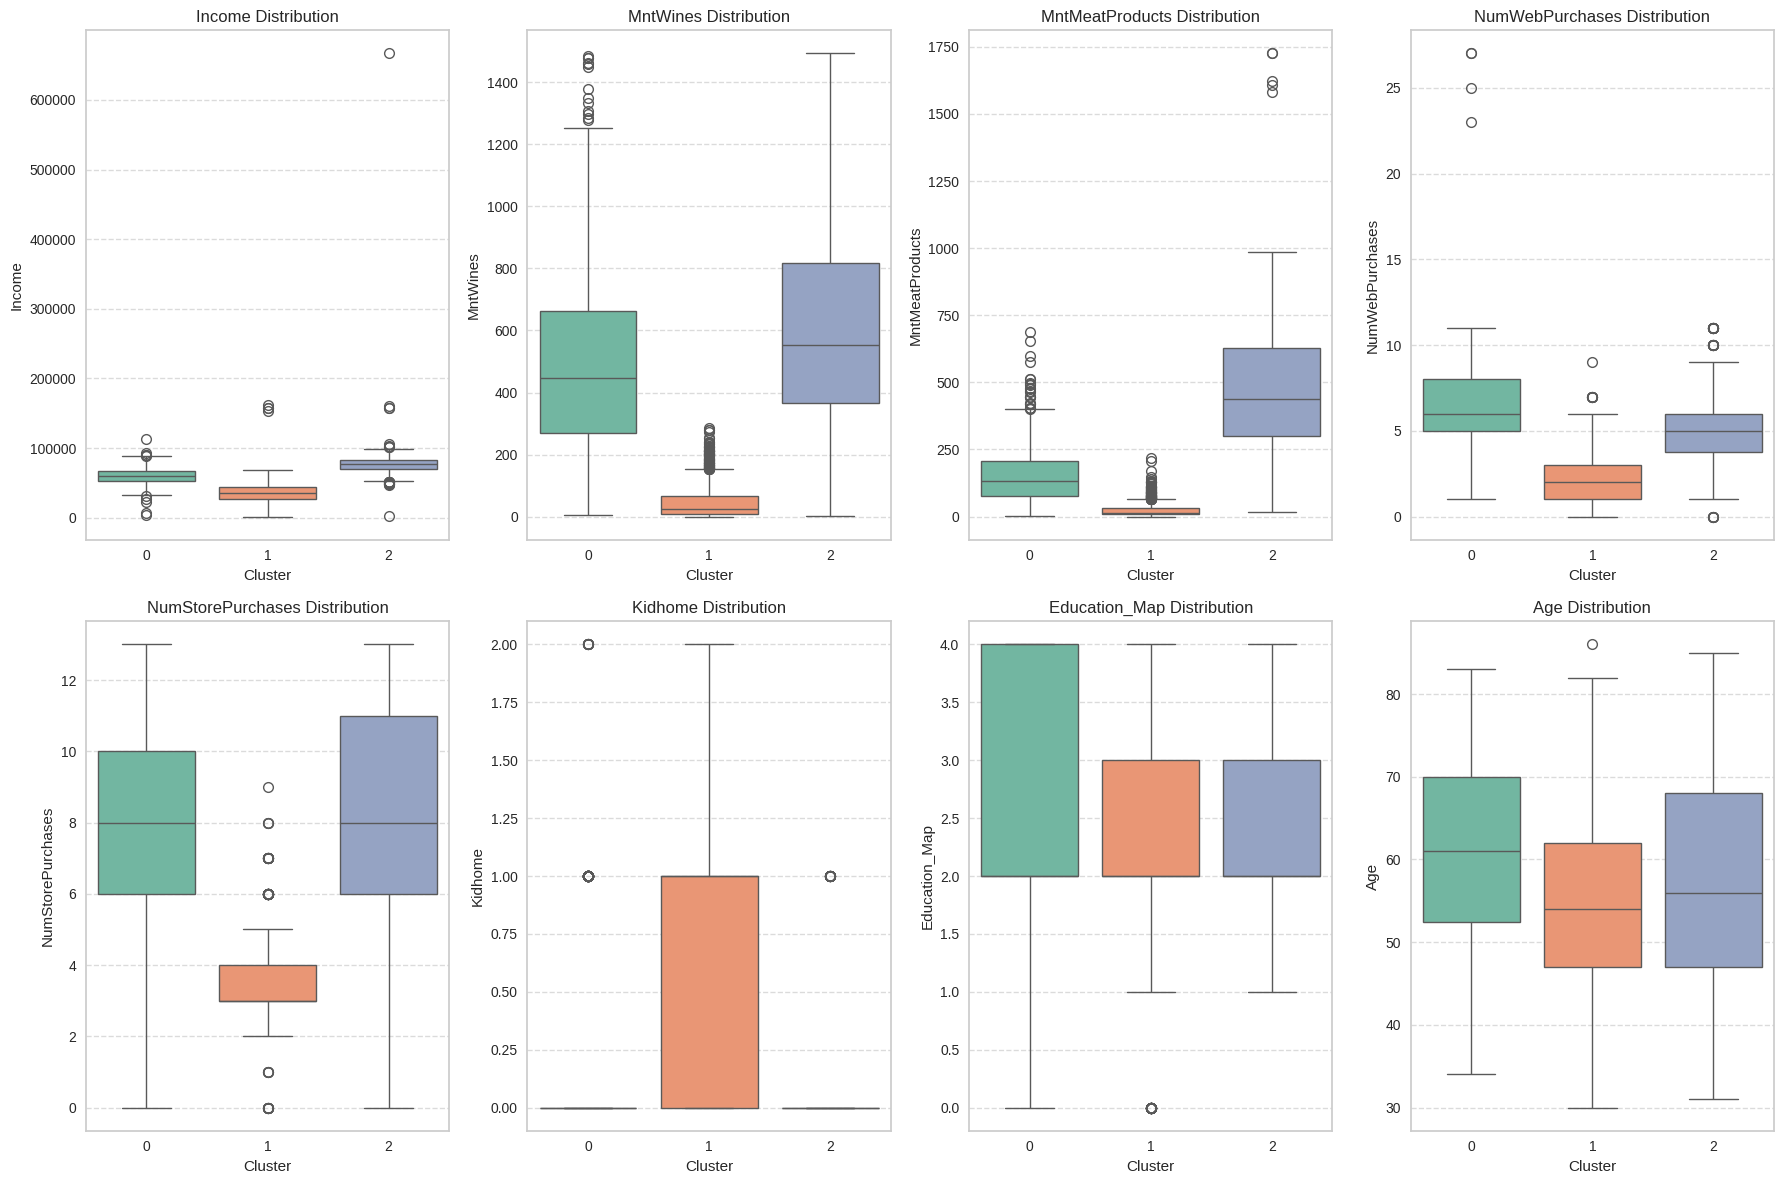

In [101]:
kmeans_final = KMeans(n_clusters=3, random_state=1, n_init=10)
data['Cluster'] = kmeans_final.fit_predict(data_scaled)
vars_estudo = ['Income', 'MntWines', 'MntMeatProducts', 'NumWebPurchases', 'NumStorePurchases', 'Kidhome', 'Education_Map', 'Age']

plt.figure(figsize=(18, 12))

for i, var in enumerate(vars_estudo):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='Cluster', y=var, data=data, palette='Set2')
    # Translated: Distribuição de -> Distribution of
    plt.title(f'{var} Distribution')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### **Observations:**
**Cluster 2:**

Income & Spending: This group exhibits a high median Income and the highest spending on Wines and Meat Products.

Purchasing Behavior: They are active across all channels, showing the highest median for NumStorePurchases and strong NumWebPurchases.

Family Structure: Consistent with high discretionary spending, they typically have no children at home.

**Cluster 1:**

Income & Spending: This cluster represents the lowest Income tier. Consequently, their spending on luxury items like wines and meat is minimal.

Demographics: This is the primary "family" segment, characterized by having at least one child at home.

Engagement: Their store and web purchase frequencies are significantly lower than Cluster 0, indicating a high sensitivity to price and a focus on essentials.

**Cluster 0:**

Income & Profile: This group sits in the middle for Income. They have a high Education_Map and a slightly higher median Age.

Behavior: They show moderate spending levels and a clear preference for Web Purchases, often outperforming Cluster 0 in this specific channel.

Family Structure: Like Cluster 0, they generally have no children at home, which allows them to spend more on hobbies and wines compared to the family segment.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

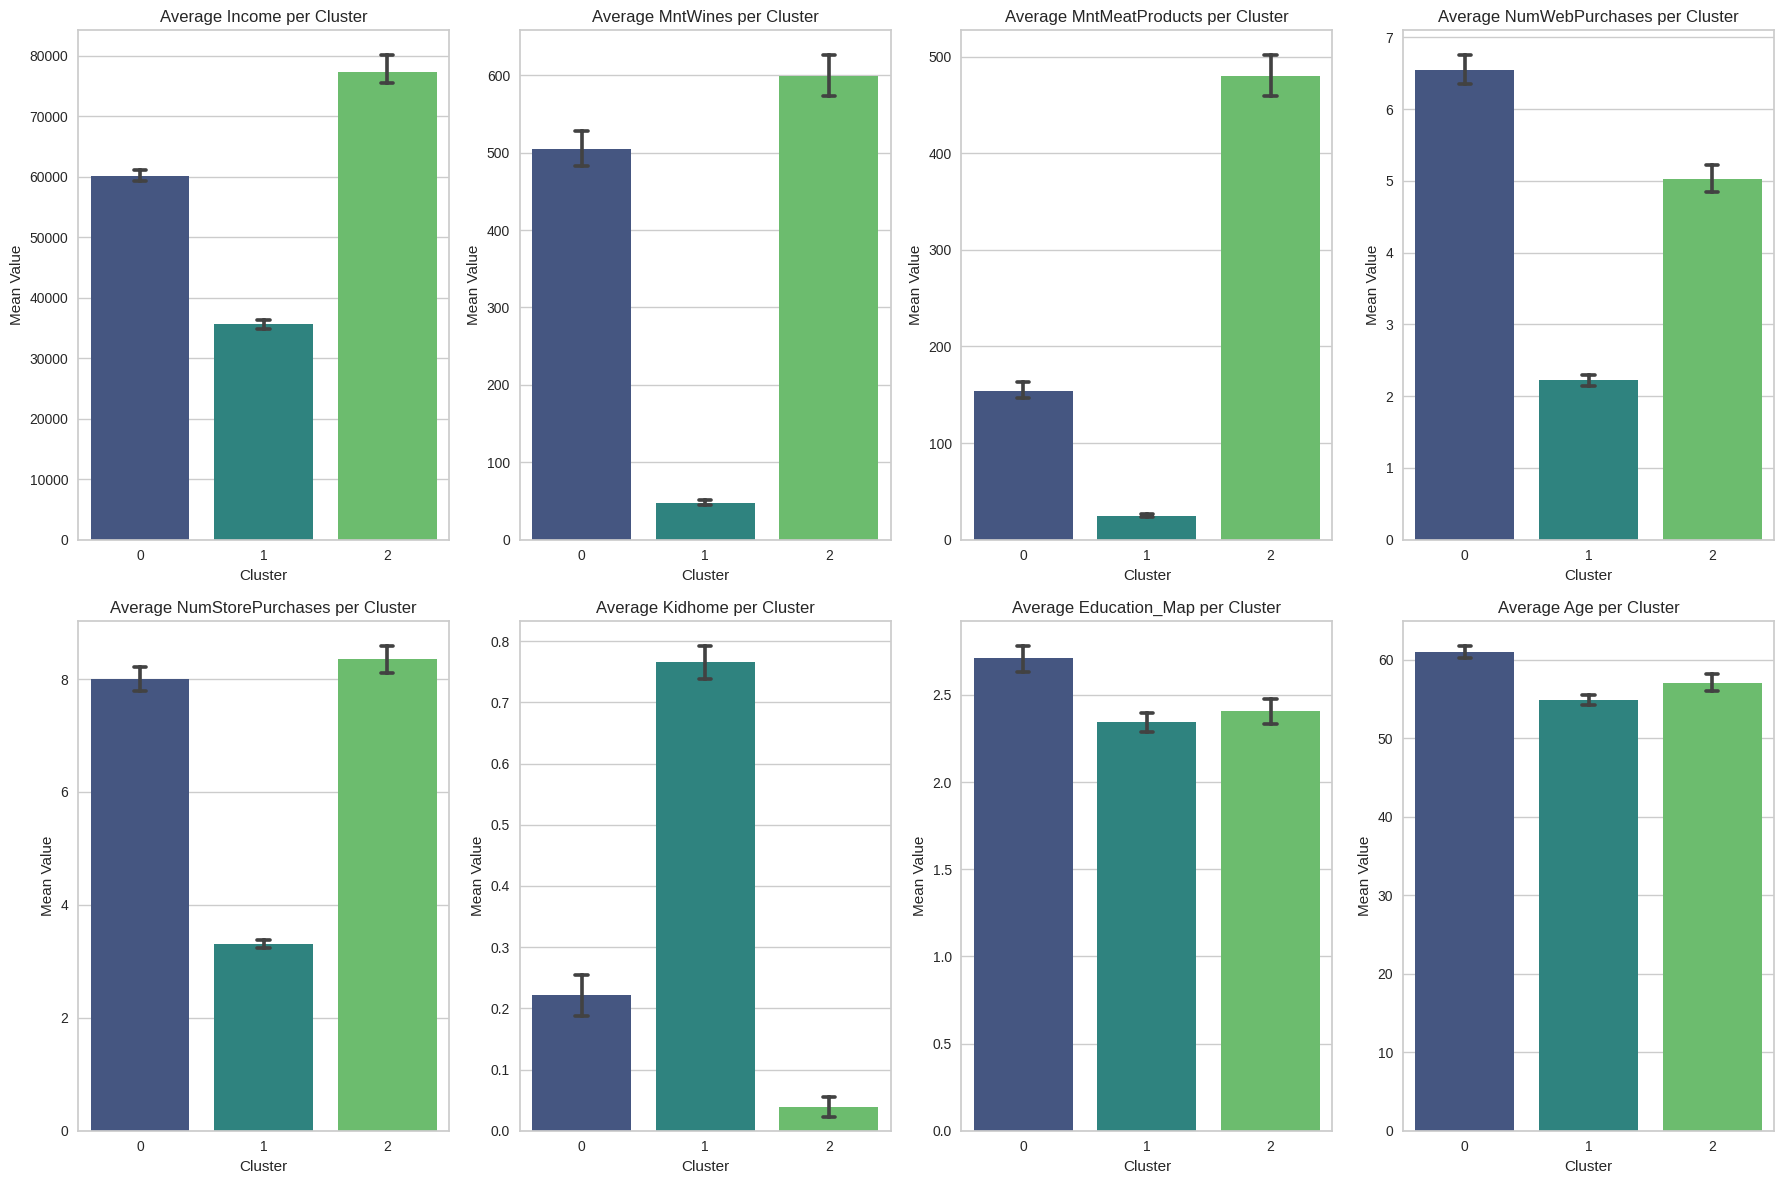

In [102]:
vars_perfil = ['Income', 'MntWines', 'MntMeatProducts', 'NumWebPurchases', 'NumStorePurchases', 'Kidhome', 'Education_Map', 'Age']

plt.figure(figsize=(18, 12))

for i, var in enumerate(vars_perfil):
    plt.subplot(2, 4, i+1)
    sns.barplot(x='Cluster', y=var, data=data, palette='viridis', capsize=.1)
    plt.title(f'Average {var} per Cluster')
    plt.ylabel('Mean Value')

plt.tight_layout()
plt.show()

##### **Observations:**
Similar to the boxplot analysis, the bar plots further validate the distinct behavior of each cluster by highlighting their average performance across key metrics:

**Cluster 2:**

As seen in the income bar plot, this group maintains a dominant Income average.

They lead significantly in the consumption of premium goods, with the highest mean values for MntWines and MntMeatProducts.

**Cluster 1:**

The bar plots clearly visualize the financial gap for this segment, showing the lowest average Income and minimal spending on wines and meat.

This group stands out in the Kidhome chart, possessing the highest average number of children at home (approx. 0.8), which likely dictates their budget allocation.

Their overall purchase frequency remains the lowest across all analyzed channels.

**Cluster 0:**

Notably, the bar plot for NumWebPurchases shows that this cluster surpasses even the elite group in digital engagement, reaching the highest average of online transactions.

They exhibit the highest average Age and Education_Map, confirming they are a highly educated, mature demographic.

While their income is lower than Cluster 0, their spending on MntWines remains substantial, indicating a clear preference for this category despite a more moderate overall budget.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

Customer segmentation is a powerful strategic tool because it allows a business to move away from a "one-size-fits-all" approach and transition into data-driven personalization. By dividing the customer base into distinct groups based on income and behavior, the company can allocate its marketing budget more efficiently, improve customer retention by offering what each group actually values, and identify specific opportunities for growth within underperforming segments. This granular view ensures that communication is relevant, increasing both conversion rates and the overall Return on Investment (ROI).

Based on the 3-cluster analysis, the following recommendations are provided:

**Group 2:** High-Income Premium Clients

Segment Profile: This group represents the highest Income bracket (avg. > $75k) and shows the highest spending on luxury categories with no children at home.

Recommendation: Focus on Exclusivity and Loyalty. Since they are the primary consumers of Wines and Meat Products, the strategy should protect this high-margin revenue.

Example Action: Implement a "VIP Wine Club" or a premium subscription service that offers early access to high-end products and exclusive in-store events.

**Group 1:** Low-Income Budget Families

Segment Profile: This group has the lowest Income (avg. ~$35k) and the highest presence of children at home (Kidhome).

Recommendation: Focus on Volume and Price Sensitivity. Their engagement is currently low, likely due to budget constraints.

Example Action: Launch "Family-Pack" bundles and aggressive discount coupons for essential items to increase their purchase frequency and brand familiarity.

**Group 0:** Mid-to-High Income Digital Enthusiasts

Segment Profile: A mature, highly educated group with solid Income (avg. ~$60k) and a clear preference for online shopping.

Recommendation: Focus on Digital Engagement and Convenience. They surpass all other groups in NumWebPurchases.

Example Action: Optimize the e-commerce experience with personalized web-only offers and educational content marketing (such as newsletters about wine pairings) to leverage their high education levels.

In [ ]:
!jupyter nbconvert --execute --to html "/content/Learner_Notebook_Full_Code_Version_Customer_Personality_Segmentation (3).ipynb"

[NbConvertApp] Converting notebook /content/Learner_Notebook_Full_Code_Version_Customer_Personality_Segmentation (3).ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp]